# **MeshFL Demo: Decentralized 3D MRI Segmentation**

Author: Mohamed Masoud

This demo showcases:
- Distributed training across multiple sites using MeshFL
- Model convergence behavior (Loss and Dice)
- Learning rate scheduling
- Final segmentation quality on a sample MRI

The goal is to demonstrate that decentralized training achieves stable convergence and meaningful segmentation performance.

Parent Project: MeshFL https://github.com/Mmasoud1/MeshFL/tree/main



---



Settings:

* **Python:** 3.10
* **Torch:** 2.0.1+cu117
* **Colab runtype:** A100 + High-RAM ON
* **CUDA available:** True
* **PYTORCH_CUDA_ALLOC_CONF:** disabled
* **Simulation result:** passed through multiple rounds with model
* **Checkpoints:** saved
* **Rounds:** 150 rounds, extended training further improves segmentation quality.  


---



## Recommend Colab Runtype:
#### **A100 + High-RAM ON**


---




### **Verify GPU**

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

!nvidia-smi

CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
Thu Apr  2 18:17:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             49W /  400W |       6MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |



### **Clone MeshFL repo**



In [2]:
!git clone https://github.com/Mmasoud1/MeshFL.git
%cd MeshFL
!ls

Cloning into 'MeshFL'...
remote: Enumerating objects: 785, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 785 (delta 41), reused 55 (delta 24), pack-reused 703 (from 1)
Receiving objects: 100% (785/785), 1.33 MiB | 22.35 MiB/s, done.
Resolving deltas: 100% (397/397), done.
Filtering content: 100% (3/3), 440.32 MiB | 10.78 MiB/s, done.
/content/MeshFL
app   LICENSE	 requirements-dev.txt  simulator_workspace  tests
css   paper	 requirements.txt      test_data
jobs  README.md  setup_paths.sh        test_output


### **Install Dependencies**

#### Install uv and Python 3.10 env

In [3]:
!which uv
!uv python install 3.10
!uv venv --python 3.10 .venv
!bash -lc 'source .venv/bin/activate && python --version'

/usr/local/bin/uv
Installed Python 3.10.20 in 1.09s
 + cpython-3.10.20-linux-x86_64-gnu (python3.10)
Using CPython 3.10.20
Creating virtual environment at: .venv
Activate with: source .venv/bin/activate
Python 3.10.20


#### Install requirements inside Python env

In [4]:
!bash -lc 'source .venv/bin/activate && python -m ensurepip --upgrade && python -m pip install -U pip setuptools wheel && python -m pip install -r requirements.txt'

Looking in links: /tmp/tmp1s5__jrd
Processing /tmp/tmp1s5__jrd/setuptools-79.0.1-py3-none-any.whl
Processing /tmp/tmp1s5__jrd/pip-23.0.1-py3-none-any.whl
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 46.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 80.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 14.2 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 79.0.1
    Uninstalling setuptools-79.0.1:
      Successfully uninstalled setuptools-79.0.1
  Attempting uninstall: pip
    Found existing installation: pip 23.0.1
    Uninstalling pip-23.0.1:
      Successfully uninstalled pip-23.0.1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of nibabel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━

#### Verify installation

In [5]:
!bash -lc 'source .venv/bin/activate && python -c "import torch, nibabel, pandas, nvflare; print(\"torch\", torch.__version__); print(\"cuda\", torch.cuda.is_available()); print(\"imports ok\")"'

torch 2.0.1+cu117
cuda True
imports ok


#### Set env vars for the shell runs

In [6]:
import os
repo_root = os.getcwd()
print("repo_root:", repo_root)

repo_root: /content/MeshFL


#### (**OPTIONAL**) - Modify number of rounds if needed for training (default 350)

Increase number of rounds further improves segmentation quality.  

In [7]:
new_num_rounds = 150  # The more the better for accuracy but the longer in training

Important: MeshFL uses one local epoch per round. Ensure `num_rounds == total_epochs`. See Wiki for details.

In [10]:
from pathlib import Path
import re


# 1. Update workflow (num_rounds)

workflow_path = Path("app/code/workflow/gradient_aggregation_workflow.py")
text = workflow_path.read_text()

text = re.sub(
    r"num_rounds:\s*int\s*=\s*\d+",
    f"num_rounds: int = {new_num_rounds}",
    text
)

workflow_path.write_text(text)
print(f"Updated num_rounds → {new_num_rounds}")


# 2. Update executor (epochs) to have same number as rounds

executor_path = Path("app/code/executor/meshnet_executor.py")
text = executor_path.read_text()

text = re.sub(
    r"self\.total_epochs\s*=\s*\d+",
    f"self.total_epochs = {new_num_rounds}",
    text
)

executor_path.write_text(text)
print(f"Updated total_epochs → {new_num_rounds}")

Updated num_rounds → 150
Updated total_epochs → 150


#### Verify correctly changed

In [11]:
!grep -n "PYTORCH_CUDA_ALLOC_CONF\|avg_grad = avg_grad.to(param.grad.dtype)\|num_rounds\|total_epochs" app/code/executor/meshnet_executor.py app/code/workflow/gradient_aggregation_workflow.py

app/code/executor/meshnet_executor.py:53:            os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
app/code/executor/meshnet_executor.py:55:                "Enabled PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True"
app/code/executor/meshnet_executor.py:57:        # Set the environment variable PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to help PyTorch handle fragmented memory
app/code/executor/meshnet_executor.py:112:        self.total_epochs = 150  # Set the total number of epochs          #<<<<<<<<<<<<<<<<<<<<<<<<
app/code/executor/meshnet_executor.py:175:            self.iterations = self.total_epochs * self.train_size
app/code/executor/meshnet_executor.py:186:                # epochs=self.total_epochs,
app/code/executor/meshnet_executor.py:195:            self.logger.log_message(f"Total epochs: {self.total_epochs}, Total iterations: {self.iterations}, lr: {self.learning_rate}")
app/code/executor/meshnet_executor.py:342:        self.logger.log_message(f"{s

### **Enable/Disable PYTORCH_CUDA_ALLOC_CONF**

This setting is optional and only needed if you encounter GPU memory issues to enables PyTorch’s expandable_segments allocator, which can reduce memory fragmentation.

In [12]:
# False disable  PYTORCH_CUDA_ALLOC_CONF
USE_EXPANDABLE_SEGMENTS = False

In [13]:
import os

if USE_EXPANDABLE_SEGMENTS:
    os.environ["MESHFL_EXPANDABLE_SEGMENTS"] = "1"
    os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
else:
    os.environ["MESHFL_EXPANDABLE_SEGMENTS"] = "0"
    if "PYTORCH_CUDA_ALLOC_CONF" in os.environ:
        del os.environ["PYTORCH_CUDA_ALLOC_CONF"]

# VERIFY
print("MESHFL_EXPANDABLE_SEGMENTS =", os.environ.get("MESHFL_EXPANDABLE_SEGMENTS"))
print("PYTORCH_CUDA_ALLOC_CONF   =", os.environ.get("PYTORCH_CUDA_ALLOC_CONF"))

MESHFL_EXPANDABLE_SEGMENTS = 0
PYTORCH_CUDA_ALLOC_CONF   = None


In [14]:
!bash -lc 'source .venv/bin/activate'

#### **Run NVFlare simulator in Python venv, GPU-enabled**


- (( n ))	number of client, for exampel 2 means two sites

- (( t ))	how many run in parallel

- num_rounds	how long training runs

In [15]:
!bash -lc 'source .venv/bin/activate && export PYTHONPATH=$(pwd)/app/code && export NVFLARE_POC_WORKSPACE=$(pwd)/poc-workspace && rm -rf simulator_workspace && nvflare simulator -w ./simulator_workspace -n 2 -t 2 ./jobs/job'

Streaming output truncated to the last 5000 lines.
2026-04-02 19:39:32,651 - FederatedClient - INFO - Starting to push execute result.
2026-04-02 19:39:32,651 - ClientRunner - INFO - [identity=site-2, run=simulate_job, peer=simulator_server, peer_run=simulate_job, task_name=accept_aggregated_gradients, task_id=7b3079ca-1554-44e1-8d0b-f20df3aafdee]: start to send task result to server
2026-04-02 19:39:32,651 - FederatedClient - INFO - Starting to push execute result.
2026-04-02 19:39:32,652 - ServerRunner - INFO - [identity=simulator_server, run=simulate_job, wf=gradient_aggregation_workflow, peer=site-1, peer_run=simulate_job]: got result from client site-1 for task: name=accept_aggregated_gradients, id=36c3f435-cc08-4b79-a710-07a4a1cb5603
2026-04-02 19:39:32,653 - ServerRunner - INFO - [identity=simulator_server, run=simulate_job, wf=gradient_aggregation_workflow, peer=site-1, peer_run=simulate_job, peer_rc=OK, task_name=accept_aggregated_gradients, task_id=36c3f435-cc08-4b79-a710-07a

### **Plots**

#### **Point to the site logs**

In [16]:
from pathlib import Path

site1_log = Path("/content/MeshFL/simulator_workspace/simulate_job/app_site-1/meshnet_executor.log")
site2_log = Path("/content/MeshFL/simulator_workspace/simulate_job/app_site-2/meshnet_executor.log")

print(site1_log.exists(), site1_log)
print(site2_log.exists(), site2_log)

True /content/MeshFL/simulator_workspace/simulate_job/app_site-1/meshnet_executor.log
True /content/MeshFL/simulator_workspace/simulate_job/app_site-2/meshnet_executor.log


#### **Parse the epoch lines**

In [17]:
import re
import pandas as pd

pattern = re.compile(
    r"Epoch \[(\d+)/(\d+)\],\s*"
    r"Train Loss:\s*([0-9.]+),\s*Val Loss:\s*([0-9.]+),\s*"
    r"Train Dice:\s*([0-9.]+),\s*Val Dice:\s*([0-9.]+),\s*lr:\s*([0-9.]+)"
)

def parse_meshnet_log(log_path, site_name):
    rows = []
    with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if m:
                epoch, total_epochs, train_loss, val_loss, train_dice, val_dice, lr = m.groups()
                rows.append({
                    "site": site_name,
                    "epoch": int(epoch),
                    "total_epochs": int(total_epochs),
                    "train_loss": float(train_loss),
                    "val_loss": float(val_loss),
                    "train_dice": float(train_dice),
                    "val_dice": float(val_dice),
                    "lr": float(lr),
                })
    return pd.DataFrame(rows)

df1 = parse_meshnet_log(site1_log, "site-1")
df2 = parse_meshnet_log(site2_log, "site-2")

df = pd.concat([df1, df2], ignore_index=True)
df

,site,epoch,total_epochs,train_loss,val_loss,train_dice,val_dice,lr
0,site-1,1,150,1.3524,1.0826,0.2876,0.3050,0.000522
1,site-1,2,150,1.0460,1.1150,0.3375,0.3198,0.000844
2,site-1,3,150,0.9297,0.9532,0.3634,0.3655,0.001166
3,site-1,4,150,0.8482,0.7880,0.3970,0.4260,0.001488
4,site-1,5,150,0.7549,0.7392,0.4487,0.4703,0.001810
...,...,...,...,...,...,...,...,...
295,site-2,146,150,0.2453,0.2364,0.8483,0.8328,0.000145
296,site-2,147,150,0.2450,0.2371,0.8488,0.8331,0.000108
297,site-2,148,150,0.2449,0.2372,0.8497,0.8324,0.000071
298,site-2,149,150,0.2449,0.2386,0.8496,0.8339,0.000034


### **Plot Train Dice/Loss**

### Training Behavior

In decentralized settings with small datasets:
- Loss is expected to decrease steadily
- Dice score should increase over time
- Minor fluctuations are normal due to:
  - small batch size (1)
  - data distribution across sites

This demo focus on overall trends rather than per-epoch noise.

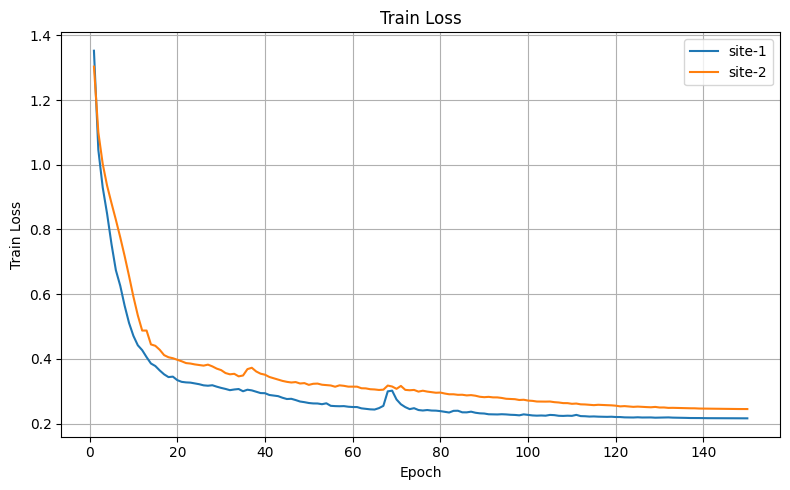

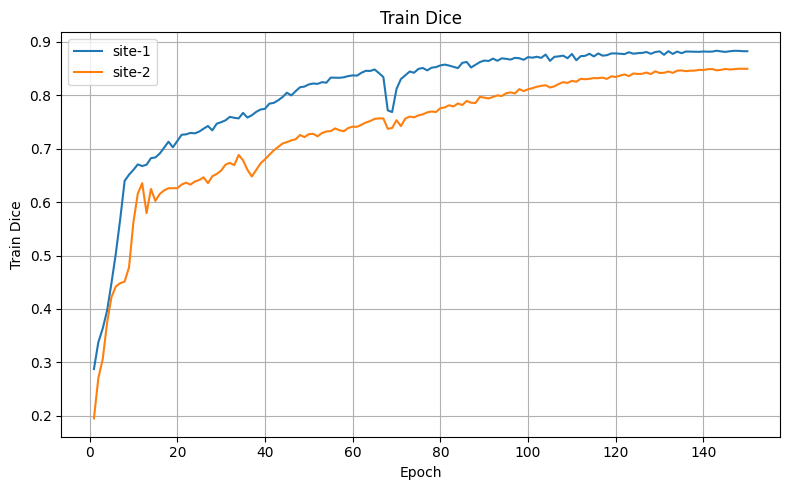

In [35]:
import matplotlib.pyplot as plt


# Train Loss
plt.figure(figsize=(8, 5))

for site_name, sub in df.groupby("site"):
    plt.plot(
        sub["epoch"],
        sub["train_loss"],
        linewidth=1.5,   # thinner line
        marker=None,     # remove markers for cleaner look
        label=site_name
    )

plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Train Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Train Dice
plt.figure(figsize=(8, 5))

for site_name, sub in df.groupby("site"):
    plt.plot(
        sub["epoch"],
        sub["train_dice"],
        linewidth=1.5,   # thinner line
        marker=None,
        label=site_name
    )

plt.xlabel("Epoch")
plt.ylabel("Train Dice")
plt.title("Train Dice")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
print("Final Train Dice per site:")
for site_name, sub in df.groupby("site"):
    final_dice = sub["train_dice"].values[-1]
    print(f"{site_name}: {final_dice:.4f}")

Final Train Dice per site:
site-1: 0.8824
site-2: 0.8495


#### Final Performance

The final Dice scores across sites demonstrate that decentralized training achieves consistent segmentation quality for 150 rounds with epoch per round.

 Increasing the rounds will improve more the dice score.

#### **Plot Val Dice/Loss**

In [38]:
def smooth_curve(y, window=7):
    import pandas as pd
    return pd.Series(y).rolling(window=window, center=True, min_periods=1).mean().values

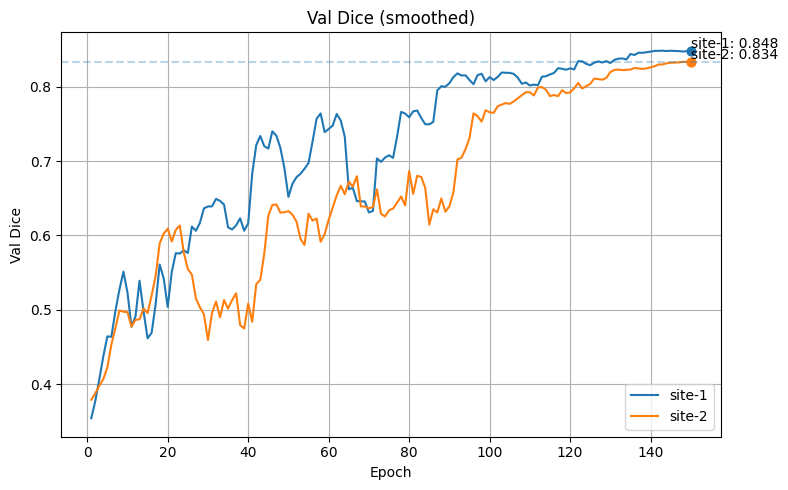

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for site_name, sub in df.groupby("site"):
    y = sub["val_dice"].values
    y_smooth = smooth_curve(y, window=7)

    x = sub["epoch"].values

    # smooth curve
    plt.plot(x, y_smooth, linewidth=1.5, label=site_name)

    # final point
    final_x = x[-1]
    final_y = y_smooth[-1]

    plt.scatter(final_x, final_y, s=40)

    plt.text(
        final_x,
        final_y,
        f"{site_name}: {final_y:.3f}",
        fontsize=10,
        verticalalignment='bottom'
    )

plt.xlabel("Epoch")
plt.ylabel("Val Dice")
plt.title("Val Dice (smoothed)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.axhline(y=final_y, linestyle="--", alpha=0.3)
plt.show()

#### **Plot Learning Rate**

/tmp/ipykernel_2464/737600387.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


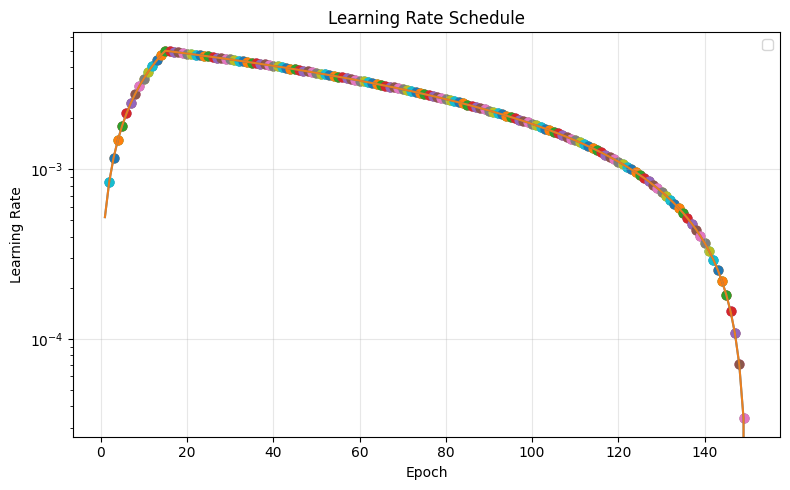

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for site_name, sub in df.groupby("site"):
    plt.plot(
        sub["epoch"],
        sub["lr"],
        linewidth=1.5,
        alpha=0.9,
        label=""
    )
for site_name, sub in df.groupby("site"):
    x = sub["epoch"].values
    y = sub["lr"].values

    for i in range(1, len(y)):
        if y[i] != y[i-1]:
            plt.scatter(x[i], y[i], s=40)


plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.grid(True, alpha=0.3)
plt.legend()

plt.yscale("log")

plt.tight_layout()
plt.show()

#### **Notes**

- Training loss decreases consistently across sites
- Dice scores improve steadily, indicating learning
- Similar trends across sites suggest stable aggregation
- Learning rate decay aligns with convergence stabilization


---



#### **Tabulate site performances**

In [21]:
df.sort_values(["site", "epoch"]).reset_index(drop=True)

,site,epoch,total_epochs,train_loss,val_loss,train_dice,val_dice,lr
0,site-1,1,150,1.3524,1.0826,0.2876,0.3050,0.000522
1,site-1,2,150,1.0460,1.1150,0.3375,0.3198,0.000844
2,site-1,3,150,0.9297,0.9532,0.3634,0.3655,0.001166
3,site-1,4,150,0.8482,0.7880,0.3970,0.4260,0.001488
4,site-1,5,150,0.7549,0.7392,0.4487,0.4703,0.001810
...,...,...,...,...,...,...,...,...
295,site-2,146,150,0.2453,0.2364,0.8483,0.8328,0.000145
296,site-2,147,150,0.2450,0.2371,0.8488,0.8331,0.000108
297,site-2,148,150,0.2449,0.2372,0.8497,0.8324,0.000071
298,site-2,149,150,0.2449,0.2386,0.8496,0.8339,0.000034


#### **Save parsed CSV**

In [22]:
df.to_csv("/content/MeshFL/parsed_training_logs.csv", index=False)
print("Saved to /content/MeshFL/parsed_training_logs.csv")

Saved to /content/MeshFL/parsed_training_logs.csv


### **Inference and Visualization**

We apply trained models to a sample MRI volume and visualize:

- Raw input slice
- Predicted segmentation
- Overlay of segmentation on MRI

This demonstrates qualitative performance of the trained model.

Using device: cuda
Sample image: /content/MeshFL/test_data/site-1/t1_c.nii.gz

Selected checkpoints:
- /content/MeshFL/test_output/simulate_job/site-1/model_epoch_0.pth
- /content/MeshFL/test_output/simulate_job/site-1/model_epoch_37.pth
- /content/MeshFL/test_output/simulate_job/site-2/model_epoch_149.pth

Input image shape: (256, 256, 256)
Orientation codes: ('R', 'A', 'S')
Saved segmentation: /content/MeshFL/test_output/inference_progress/pred_seg_epoch_0.nii.gz
Saved segmentation: /content/MeshFL/test_output/inference_progress/pred_seg_epoch_37.nii.gz
Saved segmentation: /content/MeshFL/test_output/inference_progress/pred_seg_epoch_149.nii.gz


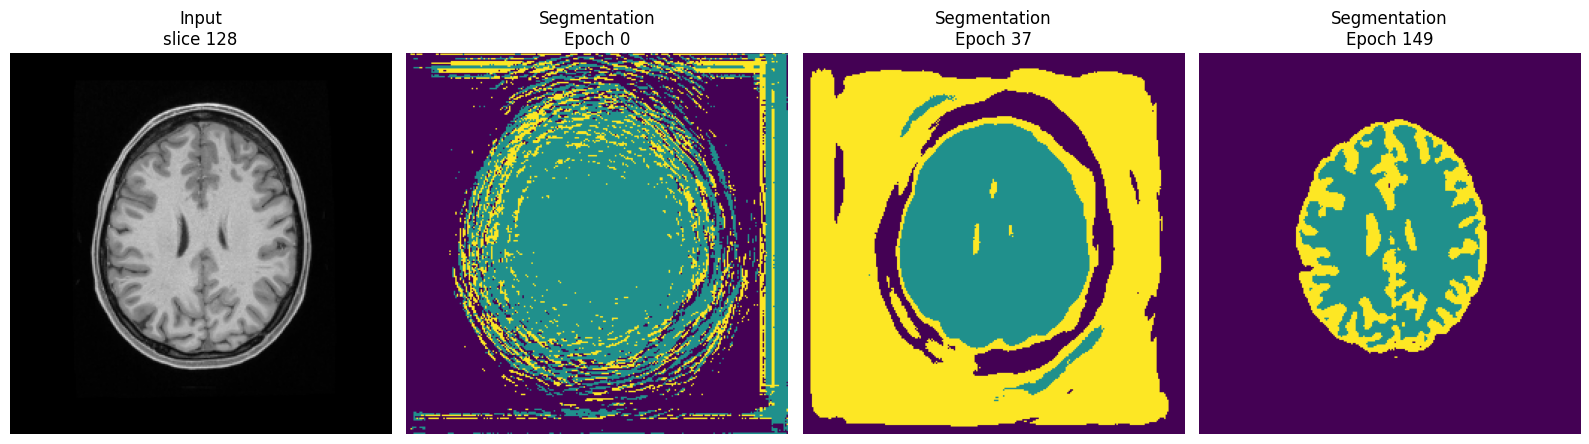

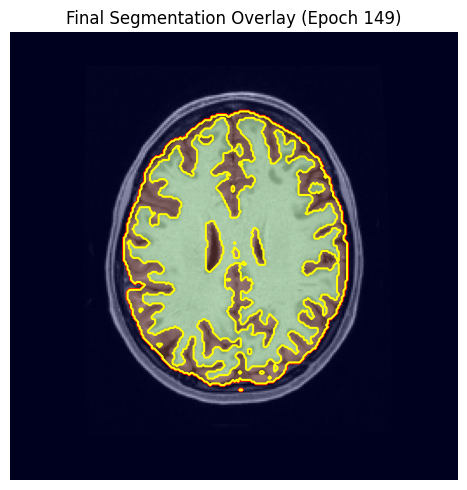

In [48]:
from pathlib import Path
import sys
import re
import torch
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


# Paths
repo_dir = Path("/content/MeshFL")
executor_dir = repo_dir / "app" / "code" / "executor"
output_dir = repo_dir / "test_output" / "inference_progress"
output_dir.mkdir(parents=True, exist_ok=True)

if str(executor_dir) not in sys.path:
    sys.path.append(str(executor_dir))

from meshnet import enMesh_checkpoint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# Find a sample image under test_data
all_nii = list(repo_dir.rglob("*.nii")) + list(repo_dir.rglob("*.nii.gz"))

def looks_like_label(p: Path):
    s = str(p).lower()
    bad_terms = ["label", "labels", "seg", "mask", "truth", "gt", "gwlabels"]
    return any(t in s for t in bad_terms)

candidate_imgs = [p for p in all_nii if "test_data" in str(p) and not looks_like_label(p)]

if not candidate_imgs:
    raise FileNotFoundError("No suitable sample image .nii/.nii.gz found under test_data.")

sample_nii = sorted(candidate_imgs)[0]
print("Sample image:", sample_nii)


# Find checkpoints
all_ckpts = sorted(repo_dir.rglob("model_epoch_*.pth"))

if not all_ckpts:
    raise FileNotFoundError("No checkpoints found (model_epoch_*.pth).")

def extract_epoch(p: Path):
    m = re.search(r"model_epoch_(\d+)\.pth$", p.name)
    return int(m.group(1)) if m else -1

all_ckpts = sorted(all_ckpts, key=extract_epoch)

if len(all_ckpts) == 1:
    selected_ckpts = all_ckpts
elif len(all_ckpts) == 2:
    selected_ckpts = all_ckpts
elif len(all_ckpts) == 3:
    selected_ckpts = all_ckpts
else:
    first = all_ckpts[0]
    middle = all_ckpts[len(all_ckpts) // 2]
    last = all_ckpts[-1]
    selected_ckpts = [first, middle, last]

print("\nSelected checkpoints:")
for c in selected_ckpts:
    print("-", c)


# Loading, canonicalizing, and normalize image

nii = nib.load(str(sample_nii))
nii = nib.as_closest_canonical(nii)  # Fix orientation for display/inference
img = nii.get_fdata().astype(np.float32)

print("\nInput image shape:", img.shape)
print("Orientation codes:", nib.aff2axcodes(nii.affine))

img_min, img_max = img.min(), img.max()
if img_max > img_min:
    img_norm = (img - img_min) / (img_max - img_min)
else:
    img_norm = img.copy()

x = torch.from_numpy(img_norm).unsqueeze(0).unsqueeze(0).to(device)

# Middle slice along last axis
mid_idx = img.shape[2] // 2


# Build model helper
config_file_path = executor_dir / "modelAE.json"

def build_model():
    model = enMesh_checkpoint(
        in_channels=1,
        n_classes=3,
        channels=5,
        config_file=str(config_file_path)
    ).to(device)
    return model

def load_checkpoint_into_model(model, ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
    elif isinstance(ckpt, dict) and "state_dict" in ckpt:
        model.load_state_dict(ckpt["state_dict"])
    else:
        model.load_state_dict(ckpt)


# Run inference for checkpoints
predictions = []

for ckpt_path in selected_ckpts:
    model = build_model()
    load_checkpoint_into_model(model, ckpt_path)
    model.eval()

    with torch.no_grad():
        logits = model(x)
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

    epoch_num = extract_epoch(ckpt_path)
    predictions.append((epoch_num, pred))

    out_path = output_dir / f"pred_seg_epoch_{epoch_num}.nii.gz"
    pred_nii = nib.Nifti1Image(pred, affine=nii.affine, header=nii.header)
    nib.save(pred_nii, str(out_path))
    print(f"Saved segmentation: {out_path}")


# Visualization of axial middle slice

n_cols = len(predictions) + 1
plt.figure(figsize=(4 * n_cols, 5))

# original image
plt.subplot(1, n_cols, 1)
plt.imshow(img_norm[:, :, mid_idx].T, cmap="gray", origin="lower")
plt.title(f"Input\nslice {mid_idx}")
plt.axis("off")

# predictions
for i, (epoch_num, pred) in enumerate(predictions, start=2):
    plt.subplot(1, n_cols, i)
    plt.imshow(pred[:, :, mid_idx].T, origin="lower")
    plt.title(f"Segmentation\nEpoch {epoch_num}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Overlay figure
plt.figure(figsize=(5, 5))

plt.imshow(img_norm[:, :, mid_idx].T, cmap="gray", origin="lower")
plt.imshow(final_pred[:, :, mid_idx].T, alpha=0.25, cmap="jet", origin="lower")
plt.contour(final_pred[:, :, mid_idx].T, levels=[0.5, 1.5], colors=["red", "yellow"])

plt.title(f"Final Segmentation Overlay (Epoch {final_epoch})")
plt.axis("off")
plt.tight_layout()
plt.show()




### Final Segmentation Result

- The model successfully identifies anatomical regions
- Boundaries align well with structural features
- Overlay visualization confirms spatial consistency

This validates that MeshFL can produce meaningful segmentation results in a decentralized setup.

### Final Notes:

- Dataset size is intentionally small for demonstration
- Validation curves may appear noisy due to:
  - batch size of 1
  - limited samples per site
- Despite this, overall trends confirm stable training

- While the model shows strong performance within **150 rounds**, extended training further improves segmentation quality.  
This demonstrates that MeshFL maintains stable learning dynamics over longer training durations.